In [1]:
import pandas as pd
import numpy as np 

In [2]:
df = pd.read_csv('../open_splice_experimental_master_unique_sequence_all_predictor_cols.tsv', sep='\t')

In [3]:
df.shape

(590104, 169)

In [4]:
# inspect if 0 or 1 occurs in the dataset
cols = [
    "alphagenome_minigene__alphagenome_minigene_acceptor_mut",
    "alphagenome_minigene__alphagenome_minigene_donor_mut"
]

for col in cols:
    print(
        col,
        df[col].min(),
        df[col].max(),
        (df[col] == 0).sum(),
        (df[col] == 1).sum()
    )

alphagenome_minigene__alphagenome_minigene_acceptor_mut 0.0 0.96875 12941 0
alphagenome_minigene__alphagenome_minigene_donor_mut 0.0 0.96875 13168 0


In [6]:
from scipy.special import logit

eps = 1e-6

acc = df[
    "alphagenome_minigene__alphagenome_minigene_acceptor_mut"
].clip(eps, 1 - eps)

don = df[
    "alphagenome_minigene__alphagenome_minigene_donor_mut"
].clip(eps, 1 - eps)

df["alphag_mut_acceptor_logit"] = logit(acc)
df["alphag_mut_donor_logit"] = logit(don)

df["alphag_mean_logit"] = df[
    ["alphag_mut_acceptor_logit", "alphag_mut_donor_logit"]
].mean(axis=1)

df["alphag_prod_logit"] = logit((acc * don).clip(eps, 1 - eps))

/var/folders/0w/9zhskz553v76zkbgq7pjk6jw0000gn/T/ipykernel_87897/1609244267.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["alphag_mean_logit"] = df[
/var/folders/0w/9zhskz553v76zkbgq7pjk6jw0000gn/T/ipykernel_87897/1609244267.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["alphag_prod_logit"] = logit((acc * don).clip(eps, 1 - eps))


In [7]:
df[[
    "alphag_mut_acceptor_logit",
    "alphag_mut_donor_logit",
    "alphag_mean_logit",
    "alphag_prod_logit"
]].describe()

,alphag_mut_acceptor_logit,alphag_mut_donor_logit,alphag_mean_logit,alphag_prod_logit
count,590104.000000,590104.000000,590104.000000,590104.000000
mean,-1.701494,-1.925883,-1.813689,-4.104376
std,2.908924,2.673756,2.460423,3.905340
min,-13.815510,-13.815510,-13.815510,-13.815510
25%,-3.039928,-2.958924,-3.142759,-6.375857
50%,-0.761322,-1.077886,-0.934979,-2.478740
75%,0.267204,-0.331117,-0.050914,-1.208594
max,3.433987,3.433987,3.433987,2.724840


In [10]:
# check splice ai distribution

spliceai_cols = [
    "spliceai_minigene__spliceai_minigene_acceptor_wt",
    "spliceai_minigene__spliceai_minigene_donor_wt",
    "spliceai_minigene__spliceai_minigene_acceptor_mut",
    "spliceai_minigene__spliceai_minigene_donor_mut",
]

for col in spliceai_cols:
    print(
        col,
        "min =", df[col].min(),
        "max =", df[col].max(),
        "zeros =", (df[col] == 0).sum(),
        "ones =", (df[col] == 1).sum(),
    )

spliceai_minigene__spliceai_minigene_acceptor_wt min = 0.0029056123457849 max = 0.9989926218986512 zeros = 0 ones = 0
spliceai_minigene__spliceai_minigene_donor_wt min = 0.008925661444664 max = 0.998262107372284 zeros = 0 ones = 0
spliceai_minigene__spliceai_minigene_acceptor_mut min = 0.0 max = 0.9994634 zeros = 12941 ones = 0
spliceai_minigene__spliceai_minigene_donor_mut min = 0.0 max = 0.9993288 zeros = 13168 ones = 0


In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import logit
from scipy.stats import linregress, pearsonr, spearmanr


# --------------------------------------------------
# Paths
# --------------------------------------------------

ROOT = Path.cwd().parent if Path.cwd().name == "analysis_script" else Path.cwd()

OUT_DIR = ROOT / "outputs" / "plots" / "alphagenome_mean_prod"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------
# Experimental logit PSI
# --------------------------------------------------

# Experimental PSI is 0-100.
# Keep this clipping, because here it is only to make PSI=0/100 finite on logit scale.
eps = 1e-8

psi_prob = (df["psi"] / 100).clip(eps, 1 - eps)
df["logit_psi"] = logit(psi_prob)


# --------------------------------------------------
# AlphaGenome absolute mutant splice-site scores
# NO clipping here
# --------------------------------------------------

acc_col = "alphagenome_minigene__alphagenome_minigene_acceptor_mut"
don_col = "alphagenome_minigene__alphagenome_minigene_donor_mut"

acc = df[acc_col]
don = df[don_col]

df["alphag_mut_acceptor_logit"] = logit(acc)
df["alphag_mut_donor_logit"] = logit(don)

df["alphag_mean_logit"] = df[
    ["alphag_mut_acceptor_logit", "alphag_mut_donor_logit"]
].mean(axis=1)

df["alphag_prod_logit"] = logit(acc * don)


# --------------------------------------------------
# Helper
# --------------------------------------------------

def get_stats(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)

    x_valid = x[mask]
    y_valid = y[mask]

    if len(x_valid) < 2 or np.ptp(x_valid) == 0 or np.ptp(y_valid) == 0:
        return None

    reg = linregress(x_valid, y_valid)
    pearson_r, _ = pearsonr(x_valid, y_valid)
    spearman_r, _ = spearmanr(x_valid, y_valid)

    return {
        "n": len(x_valid),
        "slope": reg.slope,
        "intercept": reg.intercept,
        "pearson": pearson_r,
        "spearman": spearman_r,
        "x": x_valid,
        "y": y_valid,
    }


# --------------------------------------------------
# Plot one figure per exon
# --------------------------------------------------

for exon_id, g in df.groupby("exon_id"):

    g = g.dropna(
        subset=[
            "logit_psi",
            acc_col,
            don_col,
        ]
    ).copy()

    if len(g) < 2:
        continue

    total_n = len(g)

    # Mean-logit is invalid if acceptor OR donor is zero
    mean_zero_mask = (
        (g[acc_col] == 0)
        | (g[don_col] == 0)
    )

    # Product is zero under exactly the same condition
    prod_zero_mask = (
        (g[acc_col] * g[don_col]) == 0
    )

    mean_dropped_pct = 100 * mean_zero_mask.mean()
    prod_dropped_pct = 100 * prod_zero_mask.mean()


    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 6),
    )

    comparisons = [
        (
            "alphag_mean_logit",
            "AlphaGenome mean splice-site logit",
            "Mean of acceptor/donor logits",
            mean_dropped_pct,
        ),
        (
            "alphag_prod_logit",
            "AlphaGenome product splice-site logit",
            "Logit of acceptor × donor",
            prod_dropped_pct,
        ),
    ]

    for ax, (xcol, xlabel, panel_title, dropped_pct) in zip(
        axes,
        comparisons
    ):

        stats = get_stats(
            g[xcol],
            g["logit_psi"]
        )

        if stats is None:
            ax.set_title(
                f"{panel_title}\n"
                f"Dropped zero-score variants: {dropped_pct:.1f}%"
            )
            continue

        x = stats["x"]
        y = stats["y"]

        ax.scatter(
            x,
            y,
            alpha=0.55,
            s=25
        )

        xline = np.linspace(
            x.min(),
            x.max(),
            200
        )

        yline = (
            stats["slope"] * xline
            + stats["intercept"]
        )

        ax.plot(
            xline,
            yline,
            linewidth=2
        )

        ax.set_title(
            f"{panel_title}\n"
            f"n = {stats['n']} / {total_n}, "
            f"dropped zero-score = {dropped_pct:.1f}%\n"
            f"Slope = {stats['slope']:.3f}, "
            f"Pearson r = {stats['pearson']:.3f}\n"
            f"Spearman ρ = {stats['spearman']:.3f}"
        )

        ax.set_xlabel(xlabel)
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("Measured logit PSI")
    axes[1].set_ylabel("Measured logit PSI")
    axes[1].tick_params(axis="y", labelleft=True)

    fig.suptitle(
        exon_id,
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()

    plt.savefig(
        OUT_DIR / f"{exon_id}_alphagenome_mean_prod_vs_measured.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close(fig)


print("Done.")
print("Exons:", df["exon_id"].nunique())
print("Plots saved to:", OUT_DIR)

Done.
Exons: 599
Plots saved to: /Users/liyanle/Desktop/Bioinformatics and Molecular Biology/Opensplice-analysis/outputs/plots/alphagenome_mean_prod


In [14]:
#copy 69 stubborn ones to new folder

from pathlib import Path
import shutil
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis_script" else Path.cwd()

SOURCE_DIR = ROOT / "outputs" / "plots" / "alphagenome_mean_prod"
DEST_DIR = ROOT / "outputs" / "plots" / "stubborn_75_alphagenome"

DEST_DIR.mkdir(parents=True, exist_ok=True)

stubborn = pd.read_csv(
    ROOT / "outputs" / "stubborn_75_exons.csv"
)

copied = 0
missing = []

for exon_id in stubborn["exon_id"]:
    filename = f"{exon_id}_alphagenome_mean_prod_vs_measured.png"

    src = SOURCE_DIR / filename
    dst = DEST_DIR / filename

    if src.exists():
        shutil.copy2(src, dst)
        copied += 1
    else:
        missing.append(exon_id)

print("Copied:", copied)
print("Missing:", len(missing))

if missing:
    print("Missing exons:")
    print(missing)



Copied: 69
Missing: 0


In [15]:
from pathlib import Path
import shutil

ROOT = Path.cwd().parent if Path.cwd().name == "analysis_script" else Path.cwd()

SOURCE_DIRS = [
    ROOT / "outputs" / "plots" / "stubborn_75_alphagenome",
    ROOT / "outputs" / "plots" / "stubborn_75pct",
]

DEST_DIR = ROOT / "outputs" / "plots" / "stubborn_75_combined"
DEST_DIR.mkdir(parents=True, exist_ok=True)

copied = 0

for source_dir in SOURCE_DIRS:
    for file in source_dir.iterdir():
        if file.is_file():
            shutil.copy2(file, DEST_DIR / file.name)
            copied += 1

print("Copied:", copied)
print("Combined folder:", DEST_DIR)

Copied: 138
Combined folder: /Users/liyanle/Desktop/Bioinformatics and Molecular Biology/Opensplice-analysis/outputs/plots/stubborn_75_combined


In [18]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# New output folder
# --------------------------------------------------

ROOT = Path.cwd().parent if Path.cwd().name == "analysis_script" else Path.cwd()

OUT_DIR = (
    ROOT
    / "outputs"
    / "plots"
    / "alphagenome_exonic_substitutions"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------
# Keep ONLY exonic substitutions
# --------------------------------------------------

df_sub = df[
    (df["region"] == "Exon") &
    (df["mut_type"] == "sub")
].copy()

print("Variants:", len(df_sub))
print("Exons:", df_sub["exon_id"].nunique())


# --------------------------------------------------
# Plot each exon
# --------------------------------------------------

for exon_id, g in df_sub.groupby("exon_id"):

    g = g.dropna(
        subset=[
            "logit_psi",
            acc_col,
            don_col,
        ]
    ).copy()

    if len(g) < 2:
        continue

    total_n = len(g)

    # Either splice-site probability = 0 means
    # both logit-based scores become non-finite
    zero_mask = (
        (g[acc_col] == 0) |
        (g[don_col] == 0)
    )

    dropped_pct = 100 * zero_mask.mean()

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 6),
        sharey=True
    )

    comparisons = [
        (
            "alphag_mean_logit",
            "AlphaGenome mean splice-site logit",
            "Mean of acceptor/donor logits",
        ),
        (
            "alphag_prod_logit",
            "AlphaGenome product splice-site logit",
            "Logit of acceptor × donor",
        ),
    ]

    for ax, (xcol, xlabel, panel_title) in zip(
        axes,
        comparisons
    ):

        stats = get_stats(
            g[xcol],
            g["logit_psi"]
        )

        if stats is None:
            ax.set_title(
                f"{panel_title}\n"
                f"Dropped zero-score = {dropped_pct:.1f}%"
            )
            continue

        x = stats["x"]
        y = stats["y"]

        ax.scatter(
            x,
            y,
            alpha=0.55,
            s=25
        )

        xline = np.linspace(
            x.min(),
            x.max(),
            200
        )

        yline = (
            stats["slope"] * xline
            + stats["intercept"]
        )

        ax.plot(
            xline,
            yline,
            linewidth=2
        )

        ax.set_title(
            f"{panel_title}\n"
            f"n = {stats['n']} / {total_n}, "
            f"dropped zero-score = {dropped_pct:.1f}%\n"
            f"Slope = {stats['slope']:.3f}, "
            f"Pearson r = {stats['pearson']:.3f}\n"
            f"Spearman ρ = {stats['spearman']:.3f}"
        )

        ax.set_xlabel(xlabel)
        ax.grid(alpha=0.2)

    # Repeat y-axis title + numbers on both panels
    axes[0].set_ylabel("Measured logit PSI")
    axes[1].set_ylabel("Measured logit PSI")
    axes[1].tick_params(axis="y", labelleft=True)

    fig.suptitle(
        f"{exon_id} (exonic_sub)",
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()

    plt.savefig(
        OUT_DIR
        / f"{exon_id}_alphagenome_exonic_substitutions_vs_measured.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close(fig)


print("Done.")
print("Plots saved to:", OUT_DIR)

Variants: 141948
Exons: 598
Done.
Plots saved to: /Users/liyanle/Desktop/Bioinformatics and Molecular Biology/Opensplice-analysis/outputs/plots/alphagenome_exonic_substitutions


In [20]:
from pathlib import Path
import shutil
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis_script" else Path.cwd()

SOURCE_DIR = ROOT / "outputs" / "plots" / "alphagenome_exonic_substitutions"
DEST_DIR = ROOT / "outputs" / "plots" / "stubborn_75_alphagenome"

stubborn = pd.read_csv(
    ROOT / "outputs" / "stubborn_75_exons.csv"
)

copied = 0
missing = []

for exon_id in stubborn["exon_id"]:
    filename = f"{exon_id}_alphagenome_exonic_substitutions_vs_measured.png"

    src = SOURCE_DIR / filename
    dst = DEST_DIR / filename

    if src.exists():
        shutil.copy2(src, dst)
        copied += 1
    else:
        missing.append(exon_id)

print("Copied:", copied)
print("Missing:", len(missing))

if missing:
    print(missing)

Copied: 69
Missing: 0


In [21]:
# slope distribution comparison

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --------------------------------------------------
# AlphaGenome slopes from current df
# --------------------------------------------------

alpha_rows = []

for exon_id, g in df.groupby("exon_id"):

    # Mean-logit
    x_mean = g["alphag_mean_logit"].to_numpy()
    y = g["logit_psi"].to_numpy()

    mask_mean = np.isfinite(x_mean) & np.isfinite(y)

    slope_mean = np.nan
    if mask_mean.sum() >= 2 and np.ptp(x_mean[mask_mean]) > 0:
        slope_mean = linregress(
            x_mean[mask_mean],
            y[mask_mean]
        ).slope

    # Product-logit
    x_prod = g["alphag_prod_logit"].to_numpy()

    mask_prod = np.isfinite(x_prod) & np.isfinite(y)

    slope_prod = np.nan
    if mask_prod.sum() >= 2 and np.ptp(x_prod[mask_prod]) > 0:
        slope_prod = linregress(
            x_prod[mask_prod],
            y[mask_prod]
        ).slope

    alpha_rows.append({
        "exon_id": exon_id,
        "slope_mean": slope_mean,
        "slope_prod": slope_prod,
    })

alpha_slopes = pd.DataFrame(alpha_rows)

print("AlphaGenome exons:", len(alpha_slopes))

AlphaGenome exons: 599


In [22]:
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "analysis_script" else Path.cwd()

pnas_df = pd.read_csv(
    ROOT / "outputs" / "test_exons_with_pretuner.csv"
)

pnas_rows = []

for exon_id, g in pnas_df.groupby("exon_id"):

    x = g["pretuner"].to_numpy()
    y = g["logit_psi"].to_numpy()

    mask = np.isfinite(x) & np.isfinite(y)

    slope = np.nan

    if mask.sum() >= 2 and np.ptp(x[mask]) > 0:
        slope = linregress(
            x[mask],
            y[mask]
        ).slope

    pnas_rows.append({
        "exon_id": exon_id,
        "slope_pnas": slope,
    })

pnas_slopes = pd.DataFrame(pnas_rows)

print("PNAS exons:", len(pnas_slopes))

PNAS exons: 601


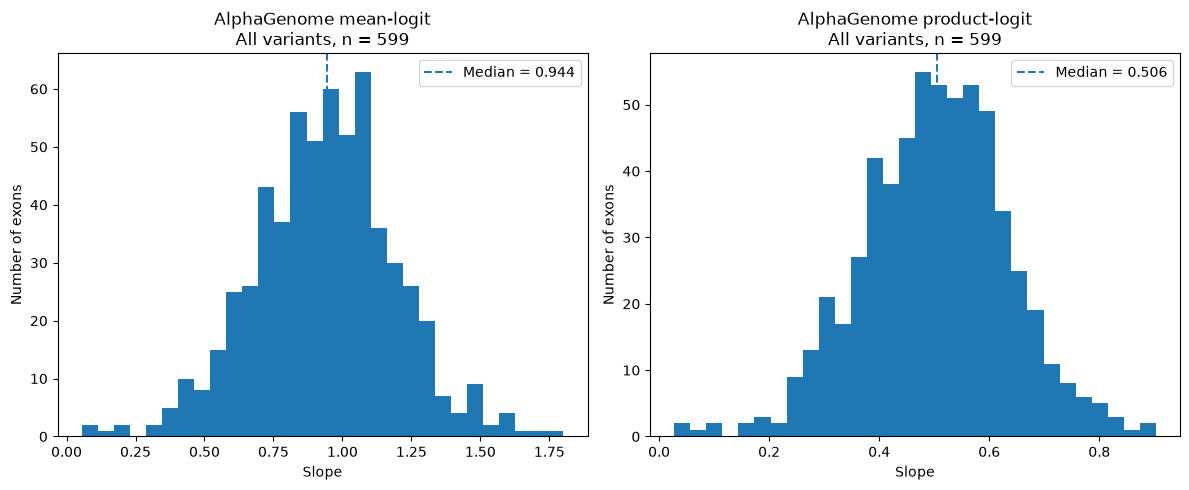

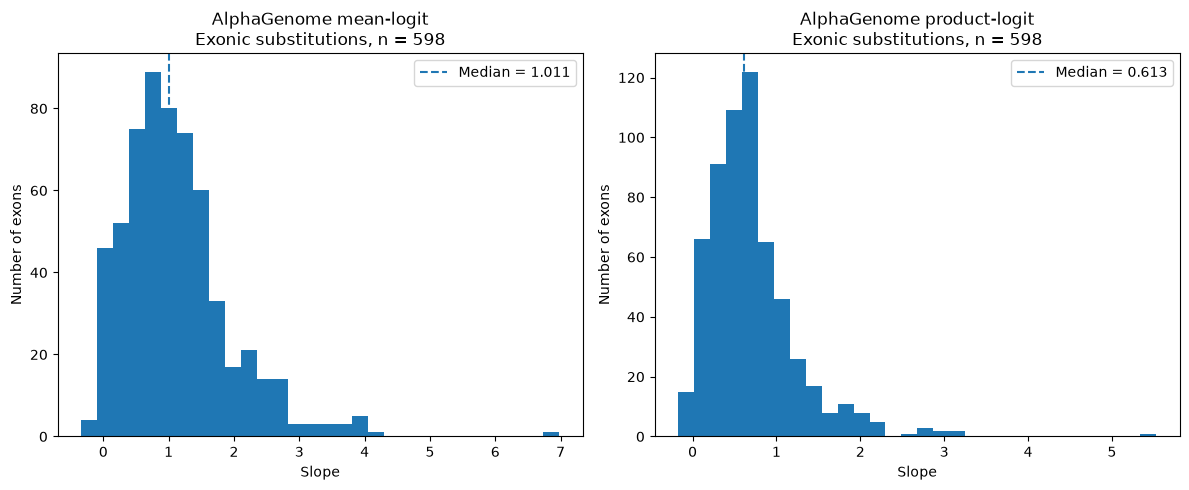

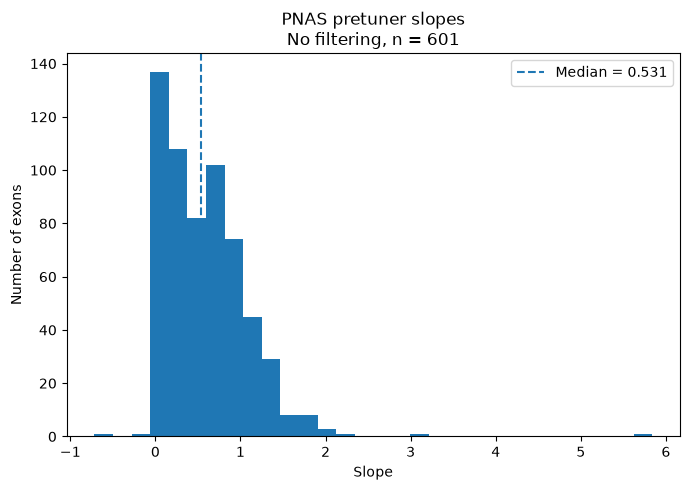

AlphaGenome all variants:
       slope_mean  slope_prod
count  599.000000  599.000000
mean     0.936674    0.501510
std      0.254669    0.132583
min      0.054925    0.027464
25%      0.771614    0.412763
50%      0.944072    0.505596
75%      1.091294    0.591111
max      1.800932    0.902829

AlphaGenome exonic substitutions:
       slope_mean_sub  slope_prod_sub
count      598.000000      598.000000
mean         1.113068        0.707339
std          0.815565        0.554571
min         -0.333941       -0.167933
25%          0.567647        0.360821
50%          1.011412        0.613142
75%          1.471684        0.896248
max          6.976913        5.526693

PNAS:
count    601.000000
mean       0.581890
std        0.508830
min       -0.715394
25%        0.189790
50%        0.530866
75%        0.868088
max        5.837938
Name: slope_pnas, dtype: float64

Saved to: /Users/liyanle/Desktop/Bioinformatics and Molecular Biology/Opensplice-analysis/outputs/plots/slope_distributions


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import linregress


# --------------------------------------------------
# Paths
# --------------------------------------------------

ROOT = Path.cwd().parent if Path.cwd().name == "analysis_script" else Path.cwd()

OUT_DIR = ROOT / "outputs" / "plots" / "slope_distributions"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------
# Helper: compute per-exon slope
# --------------------------------------------------

def compute_slopes(data, xcol, ycol="logit_psi"):

    rows = []

    for exon_id, g in data.groupby("exon_id"):

        x = g[xcol].to_numpy()
        y = g[ycol].to_numpy()

        mask = np.isfinite(x) & np.isfinite(y)

        slope = np.nan

        if (
            mask.sum() >= 2
            and np.ptp(x[mask]) > 0
            and np.ptp(y[mask]) > 0
        ):
            slope = linregress(
                x[mask],
                y[mask]
            ).slope

        rows.append({
            "exon_id": exon_id,
            "slope": slope,
        })

    return pd.DataFrame(rows)


# ==================================================
# 1. AlphaGenome — ALL variants
# ==================================================

alpha_mean = compute_slopes(
    df,
    "alphag_mean_logit"
).rename(columns={"slope": "slope_mean"})

alpha_prod = compute_slopes(
    df,
    "alphag_prod_logit"
).rename(columns={"slope": "slope_prod"})

alpha_slopes = alpha_mean.merge(
    alpha_prod,
    on="exon_id",
    how="outer"
)


# Plot
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

# Mean
x = alpha_slopes["slope_mean"].dropna()

axes[0].hist(
    x,
    bins=30
)

axes[0].axvline(
    x.median(),
    linestyle="--",
    label=f"Median = {x.median():.3f}"
)

axes[0].set_title(
    f"AlphaGenome mean-logit\n"
    f"All variants, n = {len(x)}"
)

axes[0].set_xlabel("Slope")
axes[0].set_ylabel("Number of exons")
axes[0].legend()


# Product
x = alpha_slopes["slope_prod"].dropna()

axes[1].hist(
    x,
    bins=30
)

axes[1].axvline(
    x.median(),
    linestyle="--",
    label=f"Median = {x.median():.3f}"
)

axes[1].set_title(
    f"AlphaGenome product-logit\n"
    f"All variants, n = {len(x)}"
)

axes[1].set_xlabel("Slope")
axes[1].set_ylabel("Number of exons")
axes[1].legend()

plt.tight_layout()

plt.savefig(
    OUT_DIR / "alphagenome_all_variants_slope_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ==================================================
# 2. AlphaGenome — EXONIC SUBSTITUTIONS ONLY
# ==================================================

df_exonic_sub = df[
    (df["region"] == "Exon") &
    (df["mut_type"] == "sub")
].copy()

alpha_sub_mean = compute_slopes(
    df_exonic_sub,
    "alphag_mean_logit"
).rename(columns={"slope": "slope_mean_sub"})

alpha_sub_prod = compute_slopes(
    df_exonic_sub,
    "alphag_prod_logit"
).rename(columns={"slope": "slope_prod_sub"})

alpha_sub_slopes = alpha_sub_mean.merge(
    alpha_sub_prod,
    on="exon_id",
    how="outer"
)


# Plot
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

# Mean
x = alpha_sub_slopes["slope_mean_sub"].dropna()

axes[0].hist(
    x,
    bins=30
)

axes[0].axvline(
    x.median(),
    linestyle="--",
    label=f"Median = {x.median():.3f}"
)

axes[0].set_title(
    f"AlphaGenome mean-logit\n"
    f"Exonic substitutions, n = {len(x)}"
)

axes[0].set_xlabel("Slope")
axes[0].set_ylabel("Number of exons")
axes[0].legend()


# Product
x = alpha_sub_slopes["slope_prod_sub"].dropna()

axes[1].hist(
    x,
    bins=30
)

axes[1].axvline(
    x.median(),
    linestyle="--",
    label=f"Median = {x.median():.3f}"
)

axes[1].set_title(
    f"AlphaGenome product-logit\n"
    f"Exonic substitutions, n = {len(x)}"
)

axes[1].set_xlabel("Slope")
axes[1].set_ylabel("Number of exons")
axes[1].legend()

plt.tight_layout()

plt.savefig(
    OUT_DIR / "alphagenome_exonic_substitutions_slope_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ==================================================
# 3. PNAS — NO FILTERING
# ==================================================

pnas_df = pd.read_csv(
    ROOT / "outputs" / "test_exons_with_pretuner.csv"
)

pnas_slopes = compute_slopes(
    pnas_df,
    "pretuner"
).rename(columns={"slope": "slope_pnas"})


# Plot
x = pnas_slopes["slope_pnas"].dropna()

plt.figure(
    figsize=(7, 5)
)

plt.hist(
    x,
    bins=30
)

plt.axvline(
    x.median(),
    linestyle="--",
    label=f"Median = {x.median():.3f}"
)

plt.title(
    f"PNAS pretuner slopes\n"
    f"No filtering, n = {len(x)}"
)

plt.xlabel("Slope")
plt.ylabel("Number of exons")
plt.legend()

plt.tight_layout()

plt.savefig(
    OUT_DIR / "pnas_no_filter_slope_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Summary
# --------------------------------------------------

print("AlphaGenome all variants:")
print(alpha_slopes[["slope_mean", "slope_prod"]].describe())

print("\nAlphaGenome exonic substitutions:")
print(
    alpha_sub_slopes[
        ["slope_mean_sub", "slope_prod_sub"]
    ].describe()
)

print("\nPNAS:")
print(pnas_slopes["slope_pnas"].describe())

print("\nSaved to:", OUT_DIR)

In [32]:
print('\n'.join([col for col in df.columns if 'alphagenome_minigene' in col]))

alphagenome_minigene__Identifier
alphagenome_minigene__alphagenome_minigene_acceptor_wt
alphagenome_minigene__alphagenome_minigene_donor_wt
alphagenome_minigene__alphagenome_minigene_acceptor_mut
alphagenome_minigene__alphagenome_minigene_donor_mut
alphagenome_minigene__alphagenome_minigene_delta_acceptor
alphagenome_minigene__alphagenome_minigene_delta_donor
alphagenome_minigene__alphagenome_minigene_delta_mean


In [33]:
#AlphaGenome vs PNAS predictions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import linregress, pearsonr, spearmanr


ROOT = Path.cwd().parent if Path.cwd().name == "analysis_script" else Path.cwd()

OUT_DIR = ROOT / "outputs" / "plots" / "alphagenome_vs_pnas"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# load PNAS predictions

pnas_df = pd.read_csv(
    ROOT / "outputs" / "test_exons_with_pretuner.csv"
)

print("PNAS rows:", len(pnas_df))
print("PNAS exons:", pnas_df["exon_id"].nunique())



PNAS rows: 150500
PNAS exons: 601


In [34]:
# alphagenome for exonic substitutions

ag_sub = df[
    (df["region"] == "Exon") &
    (df["mut_type"] == "sub")
].copy()

print("AlphaGenome exonic-sub rows:", len(ag_sub))
print("AlphaGenome exonic-sub exons:", ag_sub["exon_id"].nunique())

AlphaGenome exonic-sub rows: 141948
AlphaGenome exonic-sub exons: 598


In [35]:
# merge dfs

merged = pnas_df[
    ["variant_id", "exon_id", "pretuner"]
].merge(
    ag_sub[
        [
            "variant_id",
            "exon_id",
            "alphag_mean_logit",
            "alphag_prod_logit"
        ]
    ],
    on=["variant_id", "exon_id"],
    how="inner"
)

print("\nMerged rows:", len(merged))
print("Merged exons:", merged["exon_id"].nunique())


Merged rows: 141948
Merged exons: 598


In [36]:
# stats analysis

def get_stats(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)

    x = x[mask]
    y = y[mask]

    if (
        len(x) < 2
        or np.ptp(x) == 0
        or np.ptp(y) == 0
    ):
        return None

    reg = linregress(x, y)

    pearson_r, _ = pearsonr(x, y)
    spearman_r, _ = spearmanr(x, y)

    return {
        "n": len(x),
        "slope": reg.slope,
        "intercept": reg.intercept,
        "pearson": pearson_r,
        "spearman": spearman_r,
        "x": x,
        "y": y
    }

In [37]:
# figure generation 

summary_rows = []

for exon_id, g in merged.groupby("exon_id"):

    stats_mean = get_stats(
        g["pretuner"],
        g["alphag_mean_logit"]
    )

    stats_prod = get_stats(
        g["pretuner"],
        g["alphag_prod_logit"]
    )

    if stats_mean is None and stats_prod is None:
        continue

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 5)
    )

    # Mean-logit

    if stats_mean is not None:

        x = stats_mean["x"]
        y = stats_mean["y"]

        axes[0].scatter(
            x,
            y,
            s=15,
            alpha=0.6
        )

        xline = np.linspace(
            x.min(),
            x.max(),
            100
        )

        axes[0].plot(
            xline,
            stats_mean["intercept"]
            + stats_mean["slope"] * xline
        )

        axes[0].set_title(
            "AlphaGenome mean-logit\n"
            f"n = {stats_mean['n']}, "
            f"slope = {stats_mean['slope']:.3f}, "
            f"Pearson r = {stats_mean['pearson']:.3f}, "
            f"Spearman ρ = {stats_mean['spearman']:.3f}"
        )

    axes[0].set_xlabel("PNAS pretuner")
    axes[0].set_ylabel("AlphaGenome mean-logit score")


    # Product-logit

    if stats_prod is not None:

        x = stats_prod["x"]
        y = stats_prod["y"]

        axes[1].scatter(
            x,
            y,
            s=15,
            alpha=0.6
        )

        xline = np.linspace(
            x.min(),
            x.max(),
            100
        )

        axes[1].plot(
            xline,
            stats_prod["intercept"]
            + stats_prod["slope"] * xline
        )

        axes[1].set_title(
            "AlphaGenome product-logit\n"
            f"n = {stats_prod['n']}, "
            f"slope = {stats_prod['slope']:.3f}, "
            f"Pearson r = {stats_prod['pearson']:.3f}, "
            f"Spearman ρ = {stats_prod['spearman']:.3f}"
        )

    axes[1].set_xlabel("PNAS pretuner")
    axes[1].set_ylabel("AlphaGenome product-logit score")


    fig.suptitle(
        f"{exon_id} — AlphaGenome vs PNAS",
        fontsize=15
    )

    plt.tight_layout()

    plt.savefig(
        OUT_DIR / f"{exon_id}_alphagenome_vs_pnas.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()


    # summary table
    summary_rows.append({
        "exon_id": exon_id,

        "n_mean": (
            stats_mean["n"]
            if stats_mean is not None
            else np.nan
        ),
        "slope_mean": (
            stats_mean["slope"]
            if stats_mean is not None
            else np.nan
        ),
        "pearson_mean": (
            stats_mean["pearson"]
            if stats_mean is not None
            else np.nan
        ),
        "spearman_mean": (
            stats_mean["spearman"]
            if stats_mean is not None
            else np.nan
        ),

        "n_prod": (
            stats_prod["n"]
            if stats_prod is not None
            else np.nan
        ),
        "slope_prod": (
            stats_prod["slope"]
            if stats_prod is not None
            else np.nan
        ),
        "pearson_prod": (
            stats_prod["pearson"]
            if stats_prod is not None
            else np.nan
        ),
        "spearman_prod": (
            stats_prod["spearman"]
            if stats_prod is not None
            else np.nan
        )
    })


summary = pd.DataFrame(summary_rows)

summary.to_csv(
    ROOT / "outputs" / "alphagenome_vs_pnas_slopes.csv",
    index=False
)

print("\nGenerated plots:", len(summary))
print("Saved to:", OUT_DIR)

summary.head()


Generated plots: 598
Saved to: /Users/liyanle/Desktop/Bioinformatics and Molecular Biology/Opensplice-analysis/outputs/plots/alphagenome_vs_pnas


,exon_id,n_mean,slope_mean,pearson_mean,spearman_mean,n_prod,slope_prod,pearson_prod,spearman_prod
0,ABCA4_e10,277,0.525466,0.772177,0.785383,277,0.779791,0.755643,0.783422
1,ABCA4_e9,406,0.063731,0.322071,0.269224,406,0.108581,0.321847,0.268787
2,ABCB11_e12,320,0.081011,0.430453,0.436561,320,0.113687,0.437376,0.441754
3,ABCB11_e4,143,1.126774,0.885729,0.875357,143,1.986223,0.884998,0.875443
4,ABCC2_e21,387,0.231058,0.401701,0.608252,387,0.444467,0.396639,0.609002


In [38]:
# stubborn exons filtering

import shutil

stubborn = pd.read_csv(
    ROOT / "outputs" / "stubborn_75_exons.csv"
)

STUBBORN_DIR = (
    ROOT
    / "outputs"
    / "plots"
    / "stubborn_75_alphagenome_vs_pnas"
)

STUBBORN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

copied = 0
missing = []

for exon_id in stubborn["exon_id"]:

    src = (
        OUT_DIR
        / f"{exon_id}_alphagenome_vs_pnas.png"
    )

    if src.exists():

        shutil.copy2(
            src,
            STUBBORN_DIR / src.name
        )

        copied += 1

    else:
        missing.append(exon_id)

print("Copied:", copied)
print("Missing:", len(missing))

if missing:
    print(missing)

Copied: 69
Missing: 0


In [39]:
# ============================================================
# 3-panel comparison:
#   1. Experimental measured logit PSI vs PNAS
#   2. AlphaGenome mean-logit vs PNAS
#   3. AlphaGenome product-logit vs PNAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import linregress, pearsonr, spearmanr


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ROOT = Path.cwd().parent if Path.cwd().name == "analysis_script" else Path.cwd()

OUT_DIR = (
    ROOT
    / "outputs"
    / "plots"
    / "experimental_alphagenome_vs_pnas_3panel"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Load PNAS pretuner predictions
# ------------------------------------------------------------

pnas_df = pd.read_csv(
    ROOT / "outputs" / "test_exons_with_pretuner.csv"
)

print("PNAS rows:", len(pnas_df))
print("PNAS exons:", pnas_df["exon_id"].nunique())


# ------------------------------------------------------------
# 2. AlphaGenome: exonic substitutions only
# ------------------------------------------------------------

ag_sub = df[
    (df["region"] == "Exon") &
    (df["mut_type"] == "sub")
].copy()

print("AlphaGenome exonic-sub rows:", len(ag_sub))
print("AlphaGenome exonic-sub exons:", ag_sub["exon_id"].nunique())


# ------------------------------------------------------------
# 3. Merge on the SAME mutation
# ------------------------------------------------------------

merged = pnas_df[
    [
        "variant_id",
        "exon_id",
        "pretuner"
    ]
].merge(
    ag_sub[
        [
            "variant_id",
            "exon_id",
            "logit_psi",
            "alphag_mean_logit",
            "alphag_prod_logit"
        ]
    ],
    on=["variant_id", "exon_id"],
    how="inner"
)

print("\nMerged rows:", len(merged))
print("Merged exons:", merged["exon_id"].nunique())


# ------------------------------------------------------------
# 4. Statistics helper
# ------------------------------------------------------------

def get_stats(x, y):

    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)

    x = x[mask]
    y = y[mask]

    if (
        len(x) < 2
        or np.ptp(x) == 0
        or np.ptp(y) == 0
    ):
        return None

    reg = linregress(x, y)

    pearson_r, _ = pearsonr(x, y)
    spearman_r, _ = spearmanr(x, y)

    return {
        "n": len(x),
        "slope": reg.slope,
        "intercept": reg.intercept,
        "pearson": pearson_r,
        "spearman": spearman_r,
        "x": x,
        "y": y
    }


# ------------------------------------------------------------
# 5. Helper for plotting one panel
# ------------------------------------------------------------

def plot_panel(ax, stats, ylabel, title):

    if stats is None:
        ax.set_title(f"{title}\nNo valid regression")
        ax.set_xlabel("PNAS pretuner (SR balance)")
        ax.set_ylabel(ylabel)
        return

    x = stats["x"]
    y = stats["y"]

    ax.scatter(
        x,
        y,
        s=15,
        alpha=0.6
    )

    xline = np.linspace(
        x.min(),
        x.max(),
        100
    )

    ax.plot(
        xline,
        stats["intercept"] + stats["slope"] * xline
    )

    ax.set_title(
        f"{title}\n"
        f"n = {stats['n']}, "
        f"slope = {stats['slope']:.3f}\n"
        f"Pearson r = {stats['pearson']:.3f}, "
        f"Spearman ρ = {stats['spearman']:.3f}"
    )

    ax.set_xlabel("PNAS pretuner (SR balance)")
    ax.set_ylabel(ylabel)


# ------------------------------------------------------------
# 6. Generate 3-panel plot for every exon
# ------------------------------------------------------------

summary_rows = []

for exon_id, g in merged.groupby("exon_id"):

    # LEFT: experimental
    stats_exp = get_stats(
        g["pretuner"],
        g["logit_psi"]
    )

    # MIDDLE: AlphaGenome mean-logit
    stats_mean = get_stats(
        g["pretuner"],
        g["alphag_mean_logit"]
    )

    # RIGHT: AlphaGenome product-logit
    stats_prod = get_stats(
        g["pretuner"],
        g["alphag_prod_logit"]
    )

    if (
        stats_exp is None
        and stats_mean is None
        and stats_prod is None
    ):
        continue


    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5)
    )


    # LEFT
    plot_panel(
        axes[0],
        stats_exp,
        ylabel="Measured logit PSI",
        title="Experimental"
    )


    # MIDDLE
    plot_panel(
        axes[1],
        stats_mean,
        ylabel="AlphaGenome mean-logit score",
        title="AlphaGenome mean-logit"
    )


    # RIGHT
    plot_panel(
        axes[2],
        stats_prod,
        ylabel="AlphaGenome product-logit score",
        title="AlphaGenome product-logit"
    )


    fig.suptitle(
        f"{exon_id} (exonic substitutions)",
        fontsize=16,
        y=1.03
    )

    plt.tight_layout()


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    plt.savefig(
        OUT_DIR / f"{exon_id}_experimental_alphagenome_vs_pnas.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()


    # --------------------------------------------------------
    # Summary row
    # --------------------------------------------------------

    summary_rows.append({
        "exon_id": exon_id,

        # experimental
        "n_exp": (
            stats_exp["n"]
            if stats_exp is not None else np.nan
        ),
        "slope_exp": (
            stats_exp["slope"]
            if stats_exp is not None else np.nan
        ),
        "pearson_exp": (
            stats_exp["pearson"]
            if stats_exp is not None else np.nan
        ),
        "spearman_exp": (
            stats_exp["spearman"]
            if stats_exp is not None else np.nan
        ),

        # AlphaGenome mean
        "n_mean": (
            stats_mean["n"]
            if stats_mean is not None else np.nan
        ),
        "slope_mean": (
            stats_mean["slope"]
            if stats_mean is not None else np.nan
        ),
        "pearson_mean": (
            stats_mean["pearson"]
            if stats_mean is not None else np.nan
        ),
        "spearman_mean": (
            stats_mean["spearman"]
            if stats_mean is not None else np.nan
        ),

        # AlphaGenome product
        "n_prod": (
            stats_prod["n"]
            if stats_prod is not None else np.nan
        ),
        "slope_prod": (
            stats_prod["slope"]
            if stats_prod is not None else np.nan
        ),
        "pearson_prod": (
            stats_prod["pearson"]
            if stats_prod is not None else np.nan
        ),
        "spearman_prod": (
            stats_prod["spearman"]
            if stats_prod is not None else np.nan
        ),
    })


# ------------------------------------------------------------
# 7. Save summary CSV
# ------------------------------------------------------------

summary_3panel = pd.DataFrame(summary_rows)

summary_3panel.to_csv(
    ROOT
    / "outputs"
    / "experimental_alphagenome_vs_pnas_3panel_stats.csv",
    index=False
)

print("Generated:", len(summary_3panel), "exon plots")
print("Saved plots to:", OUT_DIR)

summary_3panel.head()

PNAS rows: 150500
PNAS exons: 601
AlphaGenome exonic-sub rows: 141948
AlphaGenome exonic-sub exons: 598

Merged rows: 141948
Merged exons: 598
Generated: 598 exon plots
Saved plots to: /Users/liyanle/Desktop/Bioinformatics and Molecular Biology/Opensplice-analysis/outputs/plots/experimental_alphagenome_vs_pnas_3panel


,exon_id,n_exp,slope_exp,pearson_exp,spearman_exp,n_mean,slope_mean,pearson_mean,spearman_mean,n_prod,slope_prod,pearson_prod,spearman_prod
0,ABCA4_e10,277,0.790121,0.831776,0.804291,277,0.525466,0.772177,0.785383,277,0.779791,0.755643,0.783422
1,ABCA4_e9,406,0.368992,0.613363,0.651620,406,0.063731,0.322071,0.269224,406,0.108581,0.321847,0.268787
2,ABCB11_e12,320,0.006109,0.037163,-0.007067,320,0.081011,0.430453,0.436561,320,0.113687,0.437376,0.441754
3,ABCB11_e4,143,0.742697,0.705888,0.792795,143,1.126774,0.885729,0.875357,143,1.986223,0.884998,0.875443
4,ABCC2_e21,387,0.237536,0.314070,0.572635,387,0.231058,0.401701,0.608252,387,0.444467,0.396639,0.609002


In [43]:
# ============================================================
# 3-panel density plots
#
# LEFT:   measured logit PSI vs PNAS pretuner
# MIDDLE: AlphaGenome mean-logit vs PNAS pretuner
# RIGHT:  AlphaGenome product-logit vs PNAS pretuner
#
# Uses exonic substitutions only.
# Overwrites previous 3-panel PNGs with the same filenames.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from pathlib import Path
from scipy import stats


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ROOT = Path.cwd().parent if Path.cwd().name == "analysis_script" else Path.cwd()

OUT_DIR = (
    ROOT
    / "outputs"
    / "plots"
    / "experimental_alphagenome_vs_pnas_3panel"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 1. Load PNAS pretuner predictions
# ------------------------------------------------------------

pnas_df = pd.read_csv(
    ROOT / "outputs" / "test_exons_with_pretuner.csv"
)

print("PNAS rows:", len(pnas_df))
print("PNAS exons:", pnas_df["exon_id"].nunique())


# ------------------------------------------------------------
# 2. Restrict AlphaGenome df to exonic substitutions
# ------------------------------------------------------------

ag_sub = df[
    (df["region"] == "Exon") &
    (df["mut_type"] == "sub")
].copy()

print("AlphaGenome exonic-sub rows:", len(ag_sub))
print("AlphaGenome exonic-sub exons:", ag_sub["exon_id"].nunique())


# ------------------------------------------------------------
# 3. Merge AlphaGenome and PNAS on the same variants
# ------------------------------------------------------------

merged = pnas_df[
    [
        "variant_id",
        "exon_id",
        "pretuner"
    ]
].merge(
    ag_sub[
        [
            "variant_id",
            "exon_id",
            "logit_psi",
            "alphag_mean_logit",
            "alphag_prod_logit"
        ]
    ],
    on=["variant_id", "exon_id"],
    how="inner"
)

print("\nMerged rows:", len(merged))
print("Merged exons:", merged["exon_id"].nunique())


# ------------------------------------------------------------
# 4. Density plotting helper
# ------------------------------------------------------------

def plot_histogram(
    ax,
    x,
    y,
    title,
    ylabel,
    num_bins=25
):
    x = np.asarray(x)
    y = np.asarray(y)

    # --------------------------------------------------------
    # Remove NaN / +/- inf
    # --------------------------------------------------------

    mask = np.isfinite(x) & np.isfinite(y)

    x_raw = x[mask]
    y_raw = y[mask]

    if (
        len(x_raw) < 2
        or np.ptp(x_raw) == 0
        or np.ptp(y_raw) == 0
    ):
        ax.set_title(
            f"{title}\n"
            f"No valid regression",
            fontsize=11,
            pad=10
        )

        ax.set_xlabel(
            "PNAS pretuner output (energy_out)"
        )

        ax.set_ylabel(ylabel)

        return None


    # --------------------------------------------------------
    # Clip only for visualization
    #
    # Top/bottom 0.1% are capped for the density plot.
    # Regression statistics below use x_raw/y_raw instead.
    # --------------------------------------------------------

    x_limits = np.quantile(
        x_raw,
        [0.001, 0.999]
    )

    y_limits = np.quantile(
        y_raw,
        [0.001, 0.999]
    )

    x_plot = np.clip(
        x_raw,
        x_limits[0],
        x_limits[1]
    )

    y_plot = np.clip(
        y_raw,
        y_limits[0],
        y_limits[1]
    )


    # --------------------------------------------------------
    # 2D histogram
    # --------------------------------------------------------

    counts, xbins, ybins = np.histogram2d(
        x_plot,
        y_plot,
        bins=(num_bins, num_bins)
    )

    m1 = ax.pcolormesh(
        xbins,
        ybins,
        counts.T,
        cmap="Blues",
        norm=matplotlib.colors.LogNorm(
            vmin=0.6
        )
    )

    plt.colorbar(
        m1,
        ax=ax,
        label="Count"
    )


    # --------------------------------------------------------
    # Regression/statistics on ORIGINAL unclipped values
    # --------------------------------------------------------

    r = stats.linregress(
        x_raw,
        y_raw
    )

    rho, _ = stats.spearmanr(
        x_raw,
        y_raw
    )


    # --------------------------------------------------------
    # Regression line
    # --------------------------------------------------------

    xline = np.linspace(
        x_plot.min(),
        x_plot.max(),
        100
    )

    ax.plot(
        xline,
        r.intercept + r.slope * xline,
        linewidth=1.5
    )


    # --------------------------------------------------------
    # Title + statistics ABOVE plot
    # --------------------------------------------------------

    ax.set_title(
        f"{title}\n"
        f"n = {len(x_raw)}\n"
        f"Slope = {r.slope:.3f}, Pearson r = {r.rvalue:.3f}\n"
        f"Spearman ρ = {rho:.3f}",
        fontsize=11,
        pad=10
    )


    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    ax.set_xlabel(
        "PNAS pretuner output (energy_out)"
    )

    ax.set_ylabel(ylabel)


    return {
        "n": len(x_raw),
        "slope": r.slope,
        "intercept": r.intercept,
        "pearson": r.rvalue,
        "spearman": rho
    }


# ------------------------------------------------------------
# 5. Generate 3-panel density plots
# ------------------------------------------------------------

summary_rows = []

for exon_id, g in merged.groupby("exon_id"):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 6)
    )


    # ========================================================
    # LEFT: Experimental
    # ========================================================

    stats_exp = plot_histogram(
        axes[0],
        g["pretuner"],
        g["logit_psi"],
        title="Measured logit PSI vs pretuner",
        ylabel="Measured logit PSI",
        num_bins=25
    )


    # ========================================================
    # MIDDLE: AlphaGenome mean-logit
    # ========================================================

    stats_mean = plot_histogram(
        axes[1],
        g["pretuner"],
        g["alphag_mean_logit"],
        title="AlphaGenome mean-logit vs pretuner",
        ylabel="AlphaGenome mean-logit score",
        num_bins=25
    )


    # ========================================================
    # RIGHT: AlphaGenome product-logit
    # ========================================================

    stats_prod = plot_histogram(
        axes[2],
        g["pretuner"],
        g["alphag_prod_logit"],
        title="AlphaGenome product-logit vs pretuner",
        ylabel="AlphaGenome product-logit score",
        num_bins=25
    )


    # --------------------------------------------------------
    # Overall exon title
    # --------------------------------------------------------

    fig.suptitle(
        f"{exon_id} (exonic substitutions)",
        fontsize=16,
        y=1.04
    )

    plt.tight_layout()


    # --------------------------------------------------------
    # SAME filename as before -> overwrite
    # --------------------------------------------------------

    plt.savefig(
        OUT_DIR
        / f"{exon_id}_experimental_alphagenome_vs_pnas.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()


    # --------------------------------------------------------
    # Summary stats
    # --------------------------------------------------------

    summary_rows.append({
        "exon_id": exon_id,

        # experimental
        "n_exp": (
            stats_exp["n"]
            if stats_exp is not None
            else np.nan
        ),
        "slope_exp": (
            stats_exp["slope"]
            if stats_exp is not None
            else np.nan
        ),
        "pearson_exp": (
            stats_exp["pearson"]
            if stats_exp is not None
            else np.nan
        ),
        "spearman_exp": (
            stats_exp["spearman"]
            if stats_exp is not None
            else np.nan
        ),

        # AlphaGenome mean
        "n_mean": (
            stats_mean["n"]
            if stats_mean is not None
            else np.nan
        ),
        "slope_mean": (
            stats_mean["slope"]
            if stats_mean is not None
            else np.nan
        ),
        "pearson_mean": (
            stats_mean["pearson"]
            if stats_mean is not None
            else np.nan
        ),
        "spearman_mean": (
            stats_mean["spearman"]
            if stats_mean is not None
            else np.nan
        ),

        # AlphaGenome product
        "n_prod": (
            stats_prod["n"]
            if stats_prod is not None
            else np.nan
        ),
        "slope_prod": (
            stats_prod["slope"]
            if stats_prod is not None
            else np.nan
        ),
        "pearson_prod": (
            stats_prod["pearson"]
            if stats_prod is not None
            else np.nan
        ),
        "spearman_prod": (
            stats_prod["spearman"]
            if stats_prod is not None
            else np.nan
        )
    })


# ------------------------------------------------------------
# 6. Overwrite summary CSV
# ------------------------------------------------------------

summary_3panel = pd.DataFrame(
    summary_rows
)

summary_3panel.to_csv(
    ROOT
    / "outputs"
    / "experimental_alphagenome_vs_pnas_3panel_stats.csv",
    index=False
)

print(
    "\nGenerated / overwritten:",
    len(summary_3panel),
    "plots"
)

print(
    "Saved to:",
    OUT_DIR
)


# ============================================================
# 7. Copy / overwrite the 69 stubborn-exon versions
# ============================================================

import shutil

stubborn = pd.read_csv(
    ROOT / "outputs" / "stubborn_75_exons.csv"
)

STUBBORN_DIR = (
    ROOT
    / "outputs"
    / "plots"
    / "stubborn_75_3panel"
)

STUBBORN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

copied = 0
missing = []

for exon_id in stubborn["exon_id"]:

    filename = (
        f"{exon_id}_experimental_alphagenome_vs_pnas.png"
    )

    src = OUT_DIR / filename
    dst = STUBBORN_DIR / filename

    if src.exists():

        shutil.copy2(
            src,
            dst
        )

        copied += 1

    else:
        missing.append(exon_id)

print(
    "\nStubborn plots copied / overwritten:",
    copied
)

print(
    "Missing:",
    len(missing)
)

if missing:
    print(missing)

PNAS rows: 150500
PNAS exons: 601
AlphaGenome exonic-sub rows: 141948
AlphaGenome exonic-sub exons: 598

Merged rows: 141948
Merged exons: 598

Generated / overwritten: 598 plots
Saved to: /Users/liyanle/Desktop/Bioinformatics and Molecular Biology/Opensplice-analysis/outputs/plots/experimental_alphagenome_vs_pnas_3panel

Stubborn plots copied / overwritten: 69
Missing: 0


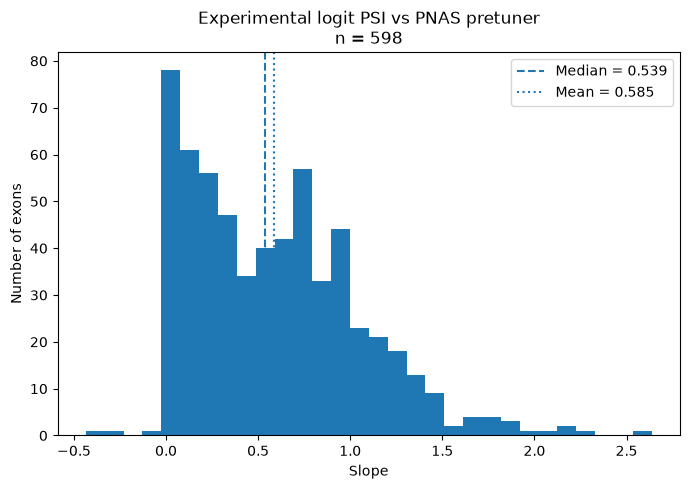

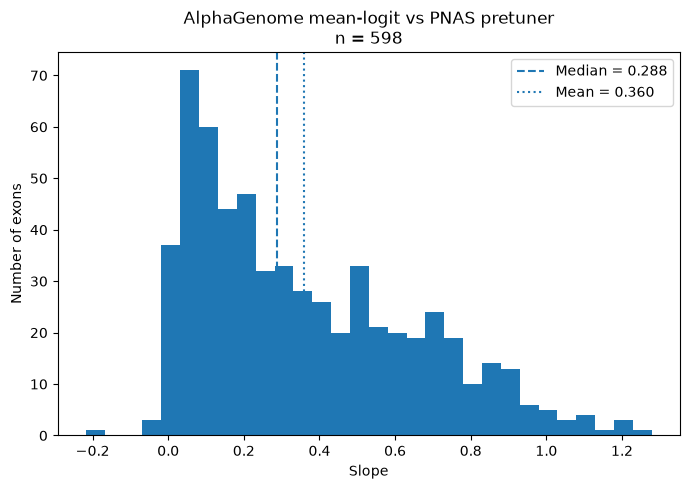

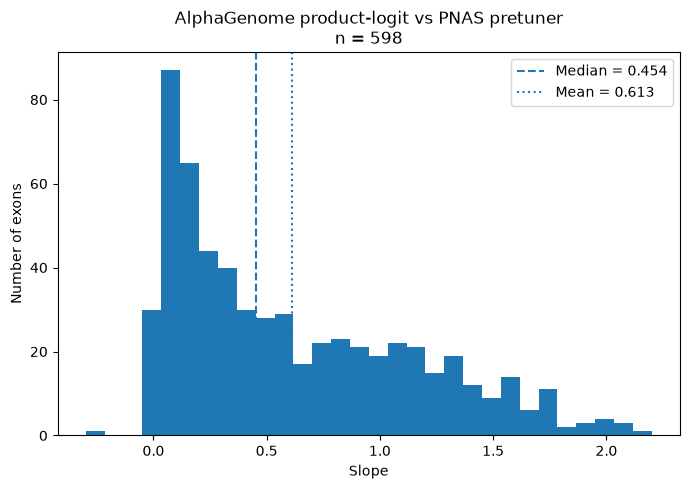

Saved to: /Users/liyanle/Desktop/Bioinformatics and Molecular Biology/Opensplice-analysis/outputs/plots/slope_distributions_3panel


In [44]:
# ============================================================
# Slope distribution histograms
# ============================================================

SLOPE_DIR = (
    ROOT
    / "outputs"
    / "plots"
    / "slope_distributions_3panel"
)

SLOPE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


def plot_slope_distribution(
    series,
    title,
    filename,
    bins=30
):
    x = series.dropna()

    plt.figure(figsize=(7, 5))

    plt.hist(
        x,
        bins=bins
    )

    plt.axvline(
        x.median(),
        linestyle="--",
        label=f"Median = {x.median():.3f}"
    )

    plt.axvline(
        x.mean(),
        linestyle=":",
        label=f"Mean = {x.mean():.3f}"
    )

    plt.title(
        f"{title}\n"
        f"n = {len(x)}"
    )

    plt.xlabel("Slope")
    plt.ylabel("Number of exons")

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        SLOPE_DIR / filename,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# 1. Experimental vs PNAS
# ------------------------------------------------------------

plot_slope_distribution(
    summary_3panel["slope_exp"],
    title="Experimental logit PSI vs PNAS pretuner",
    filename="experimental_vs_pnas_slope_distribution.png"
)


# ------------------------------------------------------------
# 2. AlphaGenome mean-logit vs PNAS
# ------------------------------------------------------------

plot_slope_distribution(
    summary_3panel["slope_mean"],
    title="AlphaGenome mean-logit vs PNAS pretuner",
    filename="alphagenome_mean_vs_pnas_slope_distribution.png"
)


# ------------------------------------------------------------
# 3. AlphaGenome product-logit vs PNAS
# ------------------------------------------------------------

plot_slope_distribution(
    summary_3panel["slope_prod"],
    title="AlphaGenome product-logit vs PNAS pretuner",
    filename="alphagenome_product_vs_pnas_slope_distribution.png"
)


print("Saved to:", SLOPE_DIR)

AlphaGenome mean-logit vs experimental stubbornness - valid exons: 598


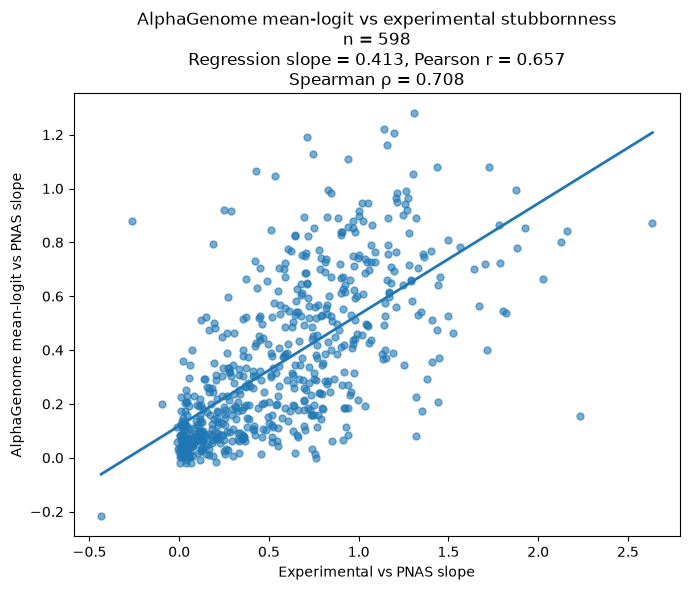

AlphaGenome product-logit vs experimental stubbornness - valid exons: 598


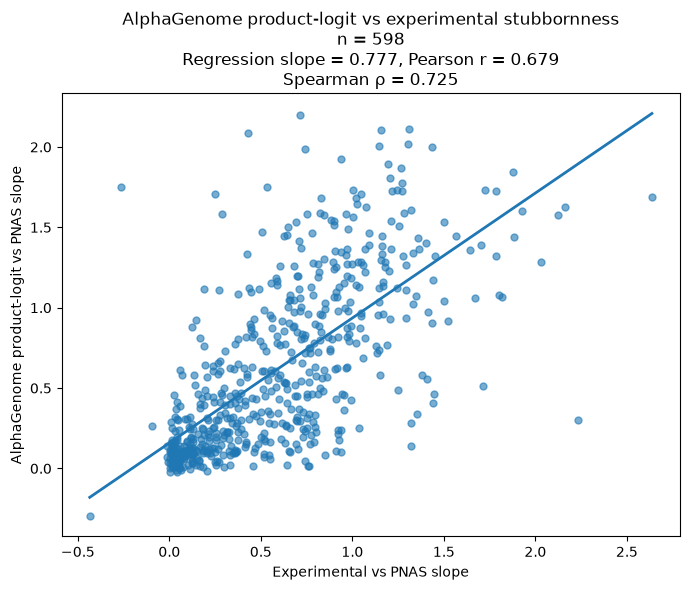


Mean-logit comparison:
{'n': 598, 'slope': 0.41299181743483904, 'intercept': 0.11852571405912699, 'pearson': 0.6568716583560104, 'spearman': 0.7077779223362332}

Product-logit comparison:
{'n': 598, 'slope': 0.7774825327788757, 'intercept': 0.15840767242959547, 'pearson': 0.6787301911806989, 'spearman': 0.7248470368436168}


In [45]:
# ============================================================
# Across-exon comparison of slopes
#
# x = experimental vs PNAS slope
# y = AlphaGenome vs PNAS slope
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path


SLOPE_COMPARE_DIR = (
    ROOT
    / "outputs"
    / "plots"
    / "alphagenome_vs_experimental_slope_comparison"
)

SLOPE_COMPARE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


def plot_slope_comparison(
    data,
    ag_slope_col,
    title,
    ylabel,
    filename
):
    # --------------------------------------------------------
    # Keep exons where BOTH slopes are valid
    # --------------------------------------------------------

    x = data["slope_exp"].to_numpy()
    y = data[ag_slope_col].to_numpy()

    mask = np.isfinite(x) & np.isfinite(y)

    x = x[mask]
    y = y[mask]

    print(title, "- valid exons:", len(x))

    # --------------------------------------------------------
    # Regression
    # --------------------------------------------------------

    reg = stats.linregress(x, y)

    rho, _ = stats.spearmanr(x, y)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    ax.scatter(
        x,
        y,
        s=25,
        alpha=0.6
    )

    # regression line
    xline = np.linspace(
        x.min(),
        x.max(),
        200
    )

    ax.plot(
        xline,
        reg.intercept + reg.slope * xline,
        linewidth=2
    )

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    ax.set_xlabel(
        "Experimental vs PNAS slope"
    )

    ax.set_ylabel(ylabel)

    ax.set_title(
        f"{title}\n"
        f"n = {len(x)}\n"
        f"Regression slope = {reg.slope:.3f}, "
        f"Pearson r = {reg.rvalue:.3f}\n"
        f"Spearman ρ = {rho:.3f}"
    )

    plt.tight_layout()

    plt.savefig(
        SLOPE_COMPARE_DIR / filename,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    return {
        "n": len(x),
        "slope": reg.slope,
        "intercept": reg.intercept,
        "pearson": reg.rvalue,
        "spearman": rho
    }


# ============================================================
# 1. AlphaGenome mean-logit slope vs experimental slope
# ============================================================

mean_compare_stats = plot_slope_comparison(
    summary_3panel,
    ag_slope_col="slope_mean",
    title="AlphaGenome mean-logit vs experimental stubbornness",
    ylabel="AlphaGenome mean-logit vs PNAS slope",
    filename="alphagenome_mean_vs_experimental_slopes.png"
)


# ============================================================
# 2. AlphaGenome product-logit slope vs experimental slope
# ============================================================

prod_compare_stats = plot_slope_comparison(
    summary_3panel,
    ag_slope_col="slope_prod",
    title="AlphaGenome product-logit vs experimental stubbornness",
    ylabel="AlphaGenome product-logit vs PNAS slope",
    filename="alphagenome_product_vs_experimental_slopes.png"
)


print("\nMean-logit comparison:")
print(mean_compare_stats)

print("\nProduct-logit comparison:")
print(prod_compare_stats)

Stubborn exons in summary: 69
AlphaGenome mean-logit vs experimental stubbornness
69 stubborn exons - valid exons: 69


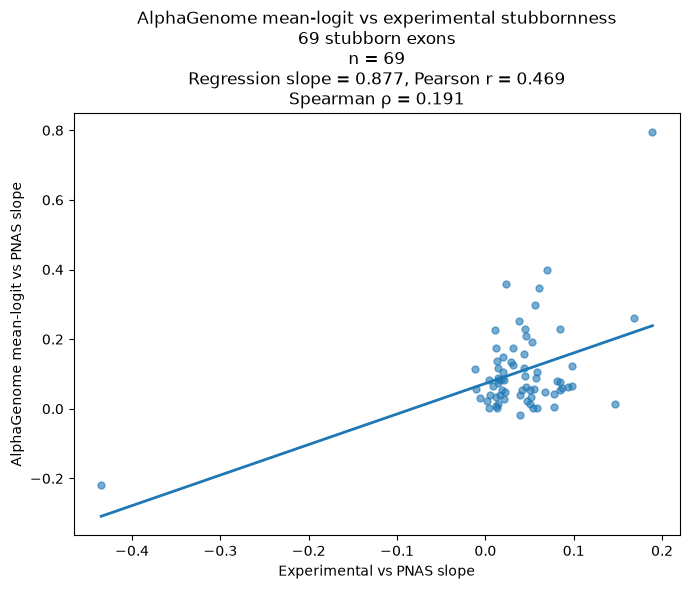

AlphaGenome product-logit vs experimental stubbornness
69 stubborn exons - valid exons: 69


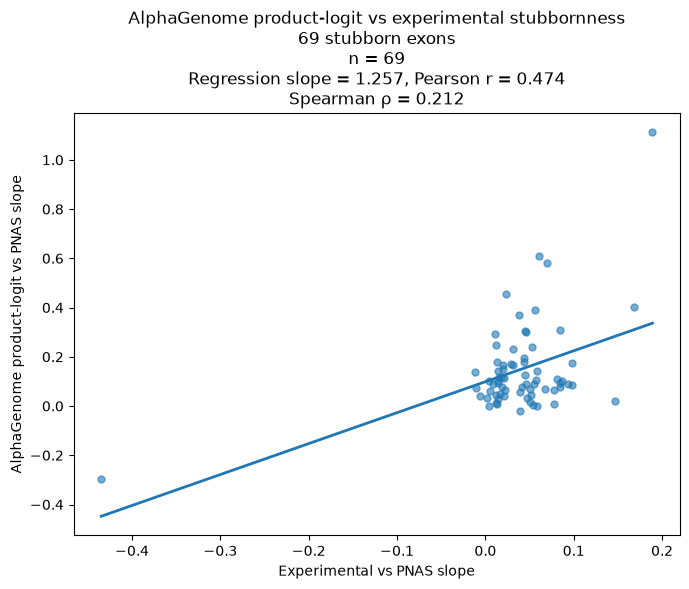


Mean-logit, stubborn 69:
{'n': 69, 'slope': 0.8773088045497713, 'intercept': 0.07270475815079355, 'pearson': 0.4690903564372416, 'spearman': 0.1914870295944465}

Product-logit, stubborn 69:
{'n': 69, 'slope': 1.2567863849374183, 'intercept': 0.09867513029754368, 'pearson': 0.47371656738331186, 'spearman': 0.21161856046766536}


In [46]:
stubborn = pd.read_csv(
    ROOT / "outputs" / "stubborn_75_exons.csv"
)

stubborn_ids = set(
    stubborn["exon_id"]
)

summary_69 = summary_3panel[
    summary_3panel["exon_id"].isin(stubborn_ids)
].copy()

print(
    "Stubborn exons in summary:",
    summary_69["exon_id"].nunique()
)

# ============================================================
# 1. Mean-logit — 69 stubborn exons
# ============================================================

mean_compare_69_stats = plot_slope_comparison(
    summary_69,
    ag_slope_col="slope_mean",
    title="AlphaGenome mean-logit vs experimental stubbornness\n69 stubborn exons",
    ylabel="AlphaGenome mean-logit vs PNAS slope",
    filename="alphagenome_mean_vs_experimental_slopes_stubborn69.png"
)


# ============================================================
# 2. Product-logit — 69 stubborn exons
# ============================================================

prod_compare_69_stats = plot_slope_comparison(
    summary_69,
    ag_slope_col="slope_prod",
    title="AlphaGenome product-logit vs experimental stubbornness\n69 stubborn exons",
    ylabel="AlphaGenome product-logit vs PNAS slope",
    filename="alphagenome_product_vs_experimental_slopes_stubborn69.png"
)


print("\nMean-logit, stubborn 69:")
print(mean_compare_69_stats)

print("\nProduct-logit, stubborn 69:")
print(prod_compare_69_stats)

In [47]:
# ============================================================
# Test whether AlphaGenome slopes differ between
# experimentally stubborn vs non-stubborn exons
#
# Experimental stubbornness cutoffs:
#   slope_exp < 0.1
#   slope_exp < 0.2
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from pathlib import Path


GROUP_COMPARE_DIR = (
    ROOT
    / "outputs"
    / "plots"
    / "alphagenome_slope_by_experimental_stubbornness"
)

GROUP_COMPARE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


def compare_groups(
    data,
    cutoff,
    ag_col,
    label,
    filename
):
    # --------------------------------------------------------
    # Keep finite experimental + AG slopes
    # --------------------------------------------------------

    d = data[
        np.isfinite(data["slope_exp"]) &
        np.isfinite(data[ag_col])
    ].copy()

    # --------------------------------------------------------
    # Define groups using EXPERIMENTAL slope
    # --------------------------------------------------------

    stubborn = d[
        d["slope_exp"] < cutoff
    ][ag_col]

    nonstubborn = d[
        d["slope_exp"] >= cutoff
    ][ag_col]

    # --------------------------------------------------------
    # Statistical tests
    # --------------------------------------------------------

    # Welch t-test: compares means
    welch = stats.ttest_ind(
        stubborn,
        nonstubborn,
        equal_var=False
    )

    # Mann-Whitney: nonparametric distribution/rank comparison
    mw = stats.mannwhitneyu(
        stubborn,
        nonstubborn,
        alternative="two-sided"
    )

    # --------------------------------------------------------
    # Effect size: difference in medians / means
    # --------------------------------------------------------

    mean_diff = stubborn.mean() - nonstubborn.mean()
    median_diff = stubborn.median() - nonstubborn.median()

    print("\n" + "=" * 60)
    print(f"{label}, experimental cutoff < {cutoff}")
    print("=" * 60)

    print(
        f"Stubborn: n={len(stubborn)}, "
        f"mean={stubborn.mean():.3f}, "
        f"median={stubborn.median():.3f}"
    )

    print(
        f"Non-stubborn: n={len(nonstubborn)}, "
        f"mean={nonstubborn.mean():.3f}, "
        f"median={nonstubborn.median():.3f}"
    )

    print(f"Mean difference: {mean_diff:.3f}")
    print(f"Median difference: {median_diff:.3f}")

    print(
        f"Welch t-test: "
        f"t={welch.statistic:.3f}, "
        f"p={welch.pvalue:.3g}"
    )

    print(
        f"Mann-Whitney: "
        f"U={mw.statistic:.1f}, "
        f"p={mw.pvalue:.3g}"
    )


    # --------------------------------------------------------
    # Plot distributions
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    ax.boxplot(
        [stubborn, nonstubborn],
        tick_labels=[
            f"Experimental slope < {cutoff}\n(n={len(stubborn)})",
            f"Experimental slope ≥ {cutoff}\n(n={len(nonstubborn)})"
        ],
        showfliers=True
    )

    # overlay individual exons with a little jitter
    rng = np.random.default_rng(0)

    x1 = rng.normal(
        1,
        0.04,
        len(stubborn)
    )

    x2 = rng.normal(
        2,
        0.04,
        len(nonstubborn)
    )

    ax.scatter(
        x1,
        stubborn,
        s=15,
        alpha=0.4
    )

    ax.scatter(
        x2,
        nonstubborn,
        s=15,
        alpha=0.4
    )

    ax.set_ylabel(
        f"{label} vs PNAS slope"
    )

    ax.set_title(
        f"{label}\n"
        f"Experimental stubborn cutoff = {cutoff}\n"
        f"Mann-Whitney p = {mw.pvalue:.3g}, "
        f"Welch p = {welch.pvalue:.3g}"
    )

    plt.tight_layout()

    plt.savefig(
        GROUP_COMPARE_DIR / filename,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


    return {
        "cutoff": cutoff,

        "n_stubborn": len(stubborn),
        "n_nonstubborn": len(nonstubborn),

        "stubborn_mean": stubborn.mean(),
        "nonstubborn_mean": nonstubborn.mean(),

        "stubborn_median": stubborn.median(),
        "nonstubborn_median": nonstubborn.median(),

        "mean_difference": mean_diff,
        "median_difference": median_diff,

        "welch_p": welch.pvalue,
        "mannwhitney_p": mw.pvalue
    }


AlphaGenome mean-logit, experimental cutoff < 0.1
Stubborn: n=98, mean=0.096, median=0.069
Non-stubborn: n=500, mean=0.412, median=0.361
Mean difference: -0.315
Median difference: -0.292
Welch t-test: t=-17.992, p=8.89e-52
Mann-Whitney: U=6524.0, p=1.42e-30


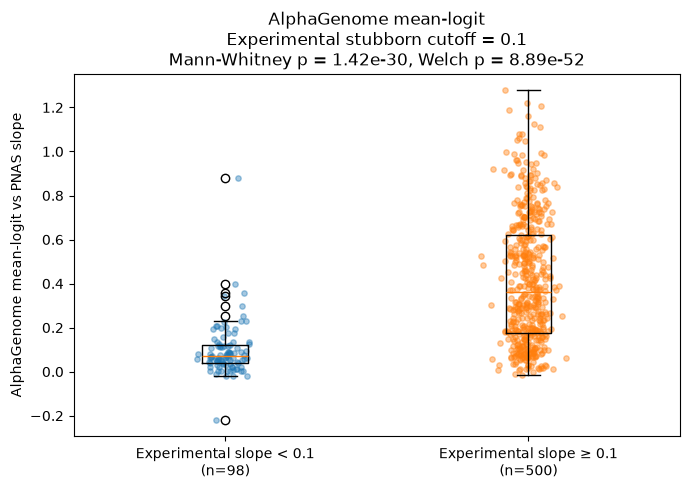


AlphaGenome product-logit, experimental cutoff < 0.1
Stubborn: n=98, mean=0.140, median=0.095
Non-stubborn: n=500, mean=0.706, median=0.603
Mean difference: -0.566
Median difference: -0.508
Welch t-test: t=-18.015, p=1.16e-52
Mann-Whitney: U=6134.0, p=7.66e-32


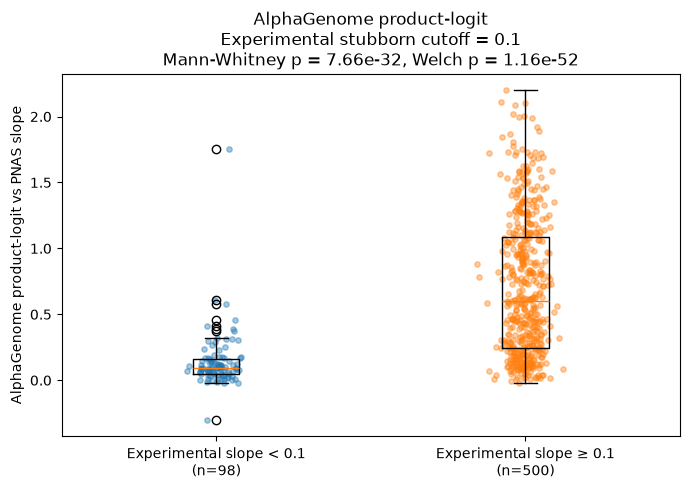


AlphaGenome mean-logit, experimental cutoff < 0.2
Stubborn: n=156, mean=0.122, median=0.082
Non-stubborn: n=442, mean=0.444, median=0.404
Mean difference: -0.323
Median difference: -0.321
Welch t-test: t=-18.504, p=1.74e-59
Mann-Whitney: U=9292.0, p=5.68e-42


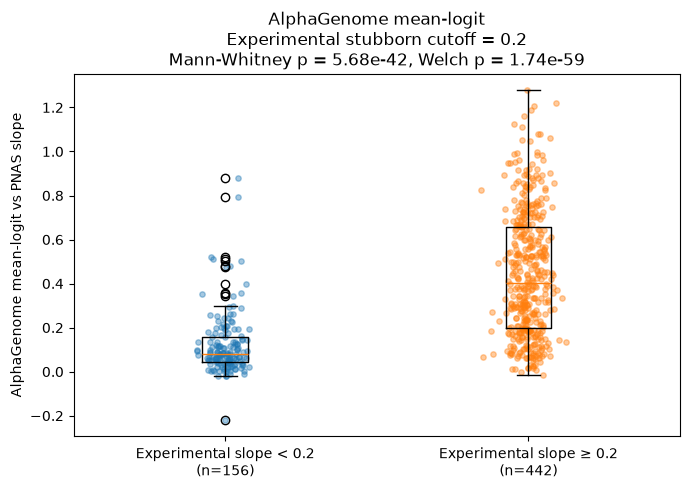


AlphaGenome product-logit, experimental cutoff < 0.2
Stubborn: n=156, mean=0.181, median=0.113
Non-stubborn: n=442, mean=0.765, median=0.702
Mean difference: -0.585
Median difference: -0.589
Welch t-test: t=-18.958, p=1.95e-62
Mann-Whitney: U=8815.0, p=1.65e-43


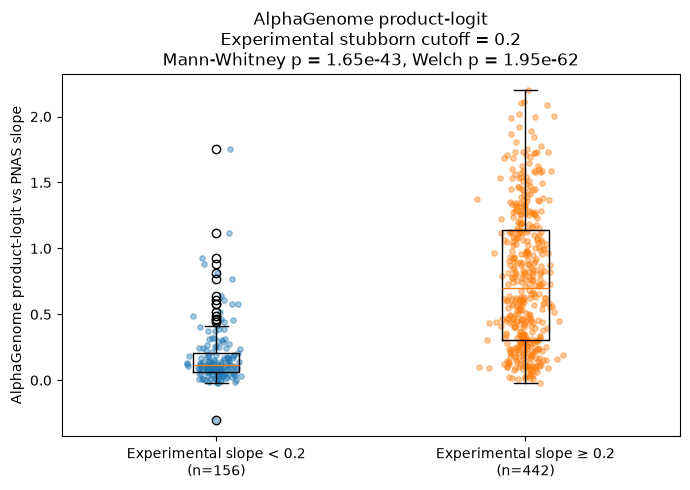

,cutoff,n_stubborn,n_nonstubborn,stubborn_mean,nonstubborn_mean,stubborn_median,nonstubborn_median,mean_difference,median_difference,welch_p,mannwhitney_p
0,0.1,98,500,0.096236,0.411632,0.068865,0.361286,-0.315395,-0.292421,8.894323e-52,1.418884e-30
1,0.1,98,500,0.139701,0.705640,0.095023,0.602922,-0.565939,-0.507900,1.160790e-52,7.664567e-32
2,0.2,156,442,0.121527,0.444093,0.082095,0.403560,-0.322566,-0.321465,1.738872e-59,5.682579e-42
3,0.2,156,442,0.180637,0.765456,0.112882,0.701790,-0.584819,-0.588908,1.945496e-62,1.645813e-43


In [48]:
results = []

# ============================================================
# cutoff = 0.1
# ============================================================

results.append(
    compare_groups(
        summary_3panel,
        cutoff=0.1,
        ag_col="slope_mean",
        label="AlphaGenome mean-logit",
        filename="mean_logit_exp_cutoff_0.1.png"
    )
)

results.append(
    compare_groups(
        summary_3panel,
        cutoff=0.1,
        ag_col="slope_prod",
        label="AlphaGenome product-logit",
        filename="product_logit_exp_cutoff_0.1.png"
    )
)


# ============================================================
# cutoff = 0.2
# ============================================================

results.append(
    compare_groups(
        summary_3panel,
        cutoff=0.2,
        ag_col="slope_mean",
        label="AlphaGenome mean-logit",
        filename="mean_logit_exp_cutoff_0.2.png"
    )
)

results.append(
    compare_groups(
        summary_3panel,
        cutoff=0.2,
        ag_col="slope_prod",
        label="AlphaGenome product-logit",
        filename="product_logit_exp_cutoff_0.2.png"
    )
)


results_df = pd.DataFrame(results)

results_df

In [49]:
# ============================================================
# Recompute 75% 10/90 saturation filter
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# ------------------------------------------------------------
# 1. Mark each variant as saturated
#
# saturated = PSI < 10 or PSI > 90
# ------------------------------------------------------------

print("pnas_df columns:")
print(pnas_df.columns.tolist())

pnas_sat = pnas_df.copy()

pnas_sat["is_saturated"] = (
    (pnas_sat["psi"] < 10) |
    (pnas_sat["psi"] > 90)
)


# ------------------------------------------------------------
# 2. Calculate saturation fraction for each exon
# ------------------------------------------------------------

saturation_by_exon = (
    pnas_sat
    .groupby("exon_id")["is_saturated"]
    .agg(
        n_variants="size",
        n_saturated="sum",
        saturation_fraction="mean"
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Apply 75% threshold
#
# PASS = fewer than 75% variants saturated
# ------------------------------------------------------------

saturation_by_exon["passes_75_10_90"] = (
    saturation_by_exon["saturation_fraction"] < 0.75
)

passing_exons = saturation_by_exon.loc[
    saturation_by_exon["passes_75_10_90"],
    "exon_id"
].tolist()

filtered_exons = saturation_by_exon.loc[
    ~saturation_by_exon["passes_75_10_90"],
    "exon_id"
].tolist()


print("Total exons:", saturation_by_exon["exon_id"].nunique())
print("Passing exons:", len(passing_exons))
print("Filtered exons:", len(filtered_exons))

pnas_df columns:
['CHROM', 'POS', 'REF', 'ALT', 'exon_id', 'ensembl_exon_id', 'variant_id', 'nt_seq', 'lib_id', 'start', 'end', 'length', 'wt', 'mut', 'mut_type', 'region', 'region_start', 'region_end', 'exon_length', 'psi_r1', 'psi_r2', 'psi_r3', 'wt_psi', 'psi', 'delta_psi', 'se_psi', 'logit_psi_wt', 'logit_psi', 'delta_logit', 'padj', 'significant', 'delta_bin', 'clinvar_mut', 'mc', 'mc_simple', 'clnsig_simple', 'status_simple', 'exon', 'pnas_exon', 'exon_with_splice_site', 'wt_seq', 'wt_length', 'wt_exon_length', 'exonic_variant', 'model_input_length', 'pretuner']
Total exons: 601
Passing exons: 518
Filtered exons: 83


In [50]:
# ============================================================
# Save saturation results
# ============================================================

saturation_by_exon.to_csv(
    ROOT / "outputs" / "saturation_75_10_90_by_exon.csv",
    index=False
)

pd.DataFrame({
    "exon_id": passing_exons
}).to_csv(
    ROOT / "outputs" / "saturation_75_10_90_passing_exons.csv",
    index=False
)

In [51]:
# ============================================================
# Restrict current matched slope analysis to unsaturated exons
# ============================================================

summary_filtered = summary_3panel[
    summary_3panel["exon_id"].isin(passing_exons)
].copy()

print("Passing exons present in summary_3panel:",
      summary_filtered["exon_id"].nunique())

Passing exons present in summary_3panel: 515


In [52]:
# ============================================================
# Compare AlphaGenome slopes:
#
# experimental slope < cutoff
# vs
# experimental slope >= cutoff
#
# AFTER saturation filtering
# ============================================================

COMPARE_DIR = (
    ROOT
    / "outputs"
    / "plots"
    / "alphagenome_stubbornness_after_saturation_filter"
)

COMPARE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


def compare_ag_slopes(data, cutoff, ag_col, ag_name, filename):

    d = data[
        np.isfinite(data["slope_exp"]) &
        np.isfinite(data[ag_col])
    ].copy()

    stubborn = d.loc[
        d["slope_exp"] < cutoff,
        ag_col
    ]

    nonstubborn = d.loc[
        d["slope_exp"] >= cutoff,
        ag_col
    ]

    # --------------------------------------------------------
    # Tests
    # --------------------------------------------------------

    welch = stats.ttest_ind(
        stubborn,
        nonstubborn,
        equal_var=False
    )

    mw = stats.mannwhitneyu(
        stubborn,
        nonstubborn,
        alternative="two-sided"
    )

    print("\n" + "=" * 65)
    print(f"{ag_name} | Experimental slope cutoff < {cutoff}")
    print("=" * 65)

    print(
        f"Low-slope: n={len(stubborn)}, "
        f"mean={stubborn.mean():.3f}, "
        f"median={stubborn.median():.3f}"
    )

    print(
        f"Higher-slope: n={len(nonstubborn)}, "
        f"mean={nonstubborn.mean():.3f}, "
        f"median={nonstubborn.median():.3f}"
    )

    print(
        f"Difference in means = "
        f"{stubborn.mean() - nonstubborn.mean():.3f}"
    )

    print(
        f"Difference in medians = "
        f"{stubborn.median() - nonstubborn.median():.3f}"
    )

    print(
        f"Welch t-test: "
        f"t={welch.statistic:.3f}, "
        f"p={welch.pvalue:.3g}"
    )

    print(
        f"Mann-Whitney: "
        f"U={mw.statistic:.1f}, "
        f"p={mw.pvalue:.3g}"
    )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    ax.boxplot(
        [stubborn, nonstubborn],
        tick_labels=[
            f"Exp slope < {cutoff}\n(n={len(stubborn)})",
            f"Exp slope ≥ {cutoff}\n(n={len(nonstubborn)})"
        ],
        showfliers=True
    )

    rng = np.random.default_rng(0)

    ax.scatter(
        rng.normal(1, 0.04, len(stubborn)),
        stubborn,
        s=18,
        alpha=0.4
    )

    ax.scatter(
        rng.normal(2, 0.04, len(nonstubborn)),
        nonstubborn,
        s=18,
        alpha=0.4
    )

    ax.set_ylabel(
        f"{ag_name} vs PNAS slope"
    )

    ax.set_title(
        f"{ag_name}\n"
        f"75% 10/90 saturation-filtered exons\n"
        f"Experimental slope cutoff = {cutoff}\n"
        f"Mann-Whitney p = {mw.pvalue:.3g}"
    )

    plt.tight_layout()

    plt.savefig(
        COMPARE_DIR / filename,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


    return {
        "definition": ag_name,
        "cutoff": cutoff,

        "n_low": len(stubborn),
        "n_high": len(nonstubborn),

        "low_mean": stubborn.mean(),
        "high_mean": nonstubborn.mean(),

        "low_median": stubborn.median(),
        "high_median": nonstubborn.median(),

        "welch_p": welch.pvalue,
        "mannwhitney_p": mw.pvalue
    }


AlphaGenome mean-logit | Experimental slope cutoff < 0.1
Low-slope: n=69, mean=0.097, median=0.074
Higher-slope: n=446, mean=0.428, median=0.384
Difference in means = -0.332
Difference in medians = -0.310
Welch t-test: t=-18.495, p=5.38e-51
Mann-Whitney: U=3847.0, p=1.11e-23


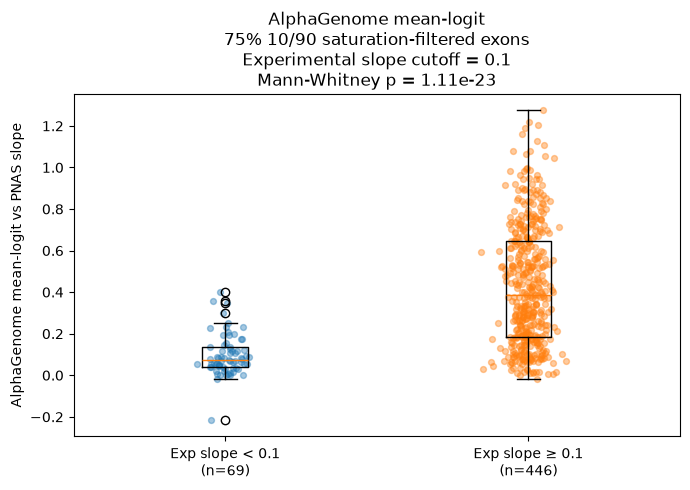


AlphaGenome product-logit | Experimental slope cutoff < 0.1
Low-slope: n=69, mean=0.133, median=0.096
Higher-slope: n=446, mean=0.734, median=0.623
Difference in means = -0.601
Difference in medians = -0.526
Welch t-test: t=-20.127, p=1.16e-62
Mann-Whitney: U=3510.0, p=5.47e-25


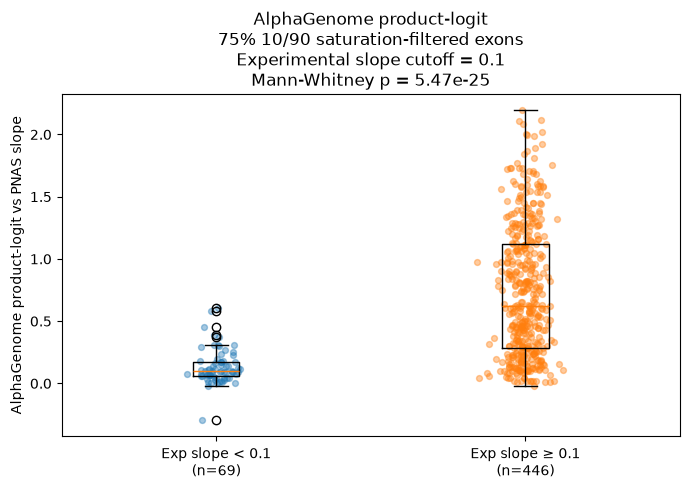


AlphaGenome mean-logit | Experimental slope cutoff < 0.2
Low-slope: n=109, mean=0.133, median=0.089
Higher-slope: n=406, mean=0.451, median=0.418
Difference in means = -0.318
Difference in medians = -0.329
Welch t-test: t=-16.324, p=3e-45
Mann-Whitney: U=6545.0, p=1.38e-29


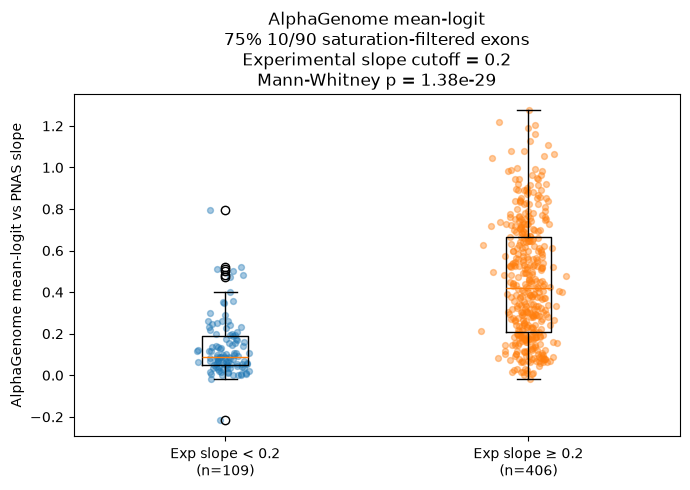


AlphaGenome product-logit | Experimental slope cutoff < 0.2
Low-slope: n=109, mean=0.193, median=0.124
Higher-slope: n=406, mean=0.777, median=0.721
Difference in means = -0.584
Difference in medians = -0.597
Welch t-test: t=-17.627, p=1.05e-52
Mann-Whitney: U=6091.0, p=3.1e-31


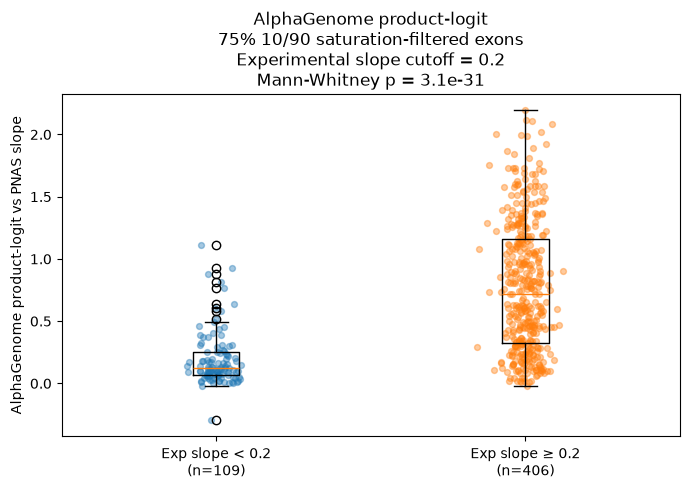

,definition,cutoff,n_low,n_high,low_mean,high_mean,low_median,high_median,welch_p,mannwhitney_p
0,AlphaGenome mean-logit,0.1,69,446,0.096583,0.428205,0.073813,0.384254,5.377815e-51,1.109521e-23
1,AlphaGenome product-logit,0.1,69,446,0.132915,0.734015,0.096471,0.622701,1.155724e-62,5.469402e-25
2,AlphaGenome mean-logit,0.2,109,406,0.132924,0.451121,0.089315,0.418011,2.999075e-45,1.383896e-29
3,AlphaGenome product-logit,0.2,109,406,0.193146,0.777066,0.124026,0.720565,1.047825e-52,3.096197e-31


In [53]:
# ============================================================
# Run 4 comparisons
# ============================================================

results = []


# cutoff 0.1
results.append(
    compare_ag_slopes(
        summary_filtered,
        cutoff=0.1,
        ag_col="slope_mean",
        ag_name="AlphaGenome mean-logit",
        filename="mean_logit_cutoff_0.1_filtered.png"
    )
)

results.append(
    compare_ag_slopes(
        summary_filtered,
        cutoff=0.1,
        ag_col="slope_prod",
        ag_name="AlphaGenome product-logit",
        filename="product_logit_cutoff_0.1_filtered.png"
    )
)


# cutoff 0.2
results.append(
    compare_ag_slopes(
        summary_filtered,
        cutoff=0.2,
        ag_col="slope_mean",
        ag_name="AlphaGenome mean-logit",
        filename="mean_logit_cutoff_0.2_filtered.png"
    )
)

results.append(
    compare_ag_slopes(
        summary_filtered,
        cutoff=0.2,
        ag_col="slope_prod",
        ag_name="AlphaGenome product-logit",
        filename="product_logit_cutoff_0.2_filtered.png"
    )
)


results_filtered = pd.DataFrame(results)

display(results_filtered)